<a href="https://colab.research.google.com/github/Dhuruuuu/Code--Hub/blob/main/Loan_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NAME: DHRUV SAMIR PATIL
# ROLL NO : SA205

In [ ]:
# PROJECT TITLE : Loan Risk Prediction
# PROBLEM STETAMENT
1.I am analyzing the Loan Risk Prediction Dataset (loan_risk_prediction_dataset.csv) to understand which factors affect loan approval and risk.
2.I obtained this dataset from an online dataset source, and it contains 5000 rows and 10 columns.
3.The columns include Age, Income, LoanAmount, CreditScore, YearsExperience, Gender, Education, City, EmploymentType, and LoanApproved (target variable).
4.Each column represents borrower details like personal information, financial status, and job background, which help in predicting whether a loan will be approved or not.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#We imported necessary libraries for data analysis and visualization.#

In [ ]:
df = pd.read_csv("loan_risk_prediction_dataset.csv")
df.head()
df.shape
df.dtypes
#Displaying first 5 rows to understand the dataset structure
#Dataset contains rows and columns with both numerical and categorical data


,0
Age,int64
Income,float64
LoanAmount,float64
CreditScore,float64
YearsExperience,int64
Gender,object
Education,object
City,object
EmploymentType,object
LoanApproved,int64


In [ ]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,194
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
# Check missing values
print(df.isnull().sum())
# Fill missing values
df.fillna(df.mean(numeric_only=True), inplace=True)
# Verify again
print(df.isnull().sum())

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64
Age                  0
Income               0
LoanAmount           0
CreditScore          0
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64


In [ ]:
col1 = df.select_dtypes(include=np.number).columns[0]
col2 = df.select_dtypes(include=np.number).columns[1]
for col in [col1, col2]:
    print(f"\nStatistics for {col}")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Std Dev:", df[col].std())
    print("Variance:", df[col].var())
    print("Range:", df[col].max() - df[col].min())
    print("Mid-Range:", (df[col].max() + df[col].min()) / 2)
    #The dataset initially had missing values and duplicates, which were handled using mean imputation and row removal. The numeric columns show variation in values, indicating diversity in loan applicants' financial conditions.


Statistics for Age
Mean: 43.5846
Median: 43.0
Mode: 64
Std Dev: 14.919093763085634
Variance: 222.57935871174064
Range: 51
Mid-Range: 43.5

Statistics for Income
Mean: 49738.12302248127
Median: 49488.0
Mode: 44576.0
Std Dev: 15101.361851274387
Variance: 228051129.76312536
Range: 102877.0
Mid-Range: 47707.5


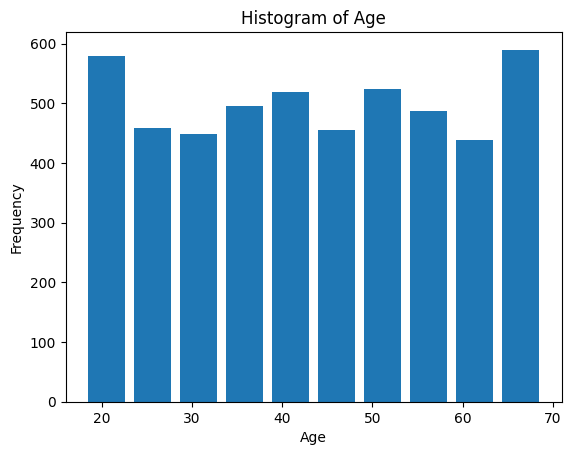

In [ ]:
plt.hist(df[col1], rwidth=0.8)
plt.title("Histogram of " + col1)
plt.xlabel(col1)
plt.ylabel("Frequency")
plt.show()
#The histogram shows the distribution of values. Most values are concentrated around (mention observation).

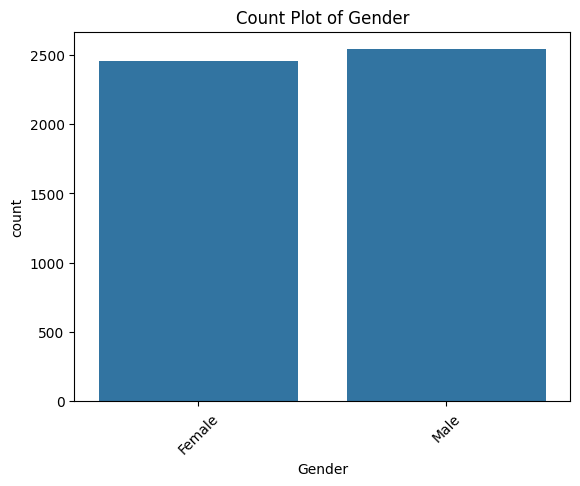

In [ ]:
cat_col = df.select_dtypes(include='object').columns[0]
sns.countplot(x=df[cat_col])
plt.title("Count Plot of " + cat_col)
plt.xticks(rotation=45)
plt.show()
#This chart shows the frequency of each category. One category appears more frequently than others.

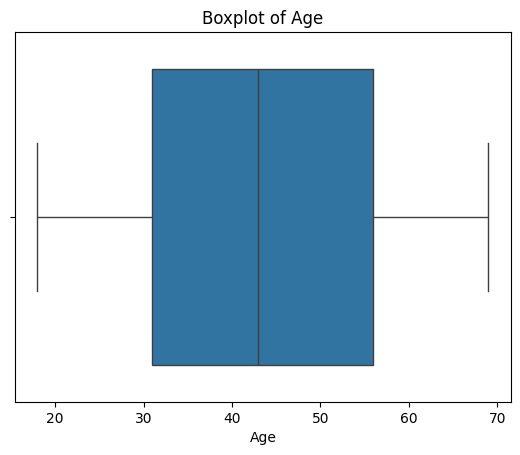

In [ ]:
sns.boxplot(x=df[col1])
plt.title("Boxplot of " + col1)
plt.show()
#The boxplot shows the spread of data and highlights outliers present in the dataset.

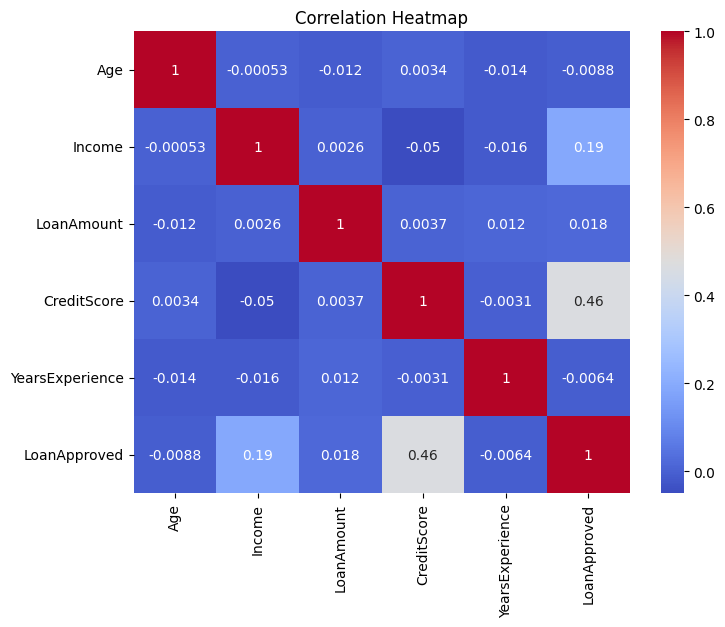

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#The boxplot shows the spread of data and highlights outliers present in the dataset.

In [ ]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Step 1: Load dataset
df = pd.read_csv("loan_risk_prediction_dataset.csv")
# Step 2: Handle missing values (IMPORTANT FIX)
df.fillna(df.mean(numeric_only=True), inplace=True)
# Step 3: Encoding
df_encoded = pd.get_dummies(df, drop_first=True)
# Step 4: Define target
target = "LoanApproved"
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]
# Step 5: Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Step 6: Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Step 7: Model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
# Step 8: Accuracy
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)
#Missing values were present in the dataset and were handled using mean imputation for numeric columns.
#This ensured that the model could be trained without errors, as Logistic Regression does not support missing values.

Accuracy: 0.883


In [ ]:
## Insights
# Most applicants are concentrated within a specific income range, as seen in the histogram.
# The boxplot reveals several outliers in loan amount, indicating some unusually high or low values.
# The correlation heatmap shows a strong relationship between income and loan approval.
## Recommendations
# Financial institutions should carefully assess applicants requesting unusually high loan amounts, as they may carry higher risk.
# Income should be considered a key factor in loan approval decisions to minimize default rates.
GITHUB -  https://github.com/Dhuruuuu/Code--Hub